<a href="https://colab.research.google.com/github/grigroman2011-oss/cepheid-research/blob/main/cepheid_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -q astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.6 MB/s eta 0:00:00


In [5]:
import astropy.units as u
from astroquery.gaia import Gaia
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
query = """
SELECT TOP 500
  c.source_id,
  g.ra,
  g.dec,
  g.parallax,
  g.parallax_error,
  c.int_average_g,
  c.pf
FROM gaiadr3.vari_cepheid AS c
JOIN gaiadr3.gaia_source AS g ON c.source_id = g.source_id
WHERE c.pf IS NOT NULL
  AND g.parallax IS NOT NULL
  AND g.parallax > 0
"""
job = Gaia.launch_job(query)
r = job.get_results()
df = r.to_pandas()
print(f"Successfully downloaded {len(df)} objects")
df.head()

Successfully downloaded 500 objects


,source_id,ra,dec,parallax,parallax_error,int_average_g,pf
0,4658055309996072960,82.410451,-69.253399,0.215860,0.124337,15.938085,26.607621
1,5313250548085699712,139.884051,-51.620424,0.196935,0.016584,12.692544,3.354941
2,4659206773546904576,87.442483,-67.877392,0.068153,0.093091,17.917120,2.755123
3,2161786374436607616,315.026581,42.597550,0.795426,0.018621,8.415941,14.712201
4,5520506531407532928,121.800220,-45.065911,0.042145,0.013623,14.001732,2.773086


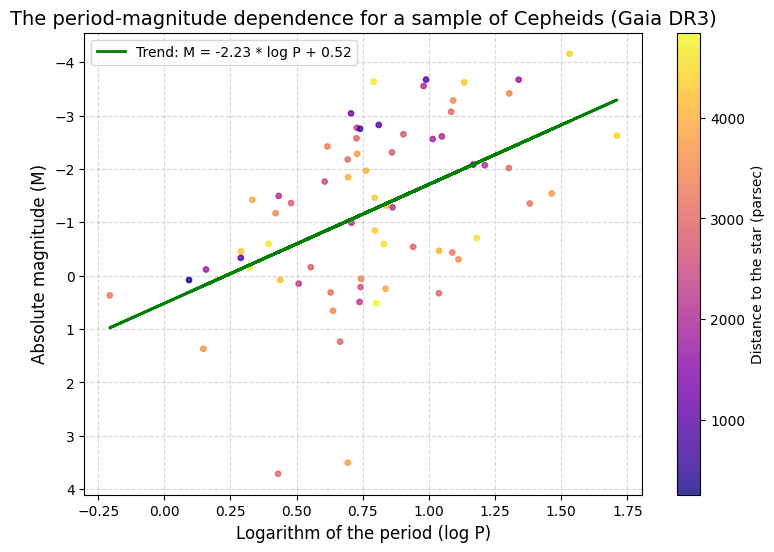

In [47]:
df['distance_pc'] = 1000.0 / df['parallax']
df['M'] = df['int_average_g'] - 5 * np.log10(df['distance_pc']) + 5
df_clean = df[(df['parallax'] / df['parallax_error'] > 5) & (df['distance_pc'] < 5000) & (df['M'] >= -10) & (df['M'] <= 10)].copy()
df_clean['M'] = df_clean['int_average_g'] - 5 * np.log10(df_clean['distance_pc']) + 5
df_clean['log_period'] = np.log10(df_clean['pf'])
x_clean = df_clean['log_period']
y_clean = df_clean['M']
a, b = np.polyfit(x_clean, y_clean, 1)
plt.figure(figsize=(9, 6))
plt.scatter(df_clean['log_period'], df_clean['M'], c=df_clean['distance_pc'], cmap='plasma', s=15, alpha=0.8)
plt.plot(x_clean, a * x_clean + b, color='green', linewidth=2, label=f'Trend: M = {a:.2f} * log P + {b:.2f}')
plt.legend(loc='upper left')
plt.colorbar(label='Distance to the star (parsec)')
plt.gca().invert_yaxis()
plt.xlabel('Logarithm of the period (log P)', fontsize=12)
plt.ylabel('Absolute magnitude (M)', fontsize=12)
plt.title('The period-magnitude dependence for a sample of Cepheids (Gaia DR3)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()